# Imports 

In [1]:
import pandas as pd 
import torch 
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


# Loading and Exploring data

In [2]:
#Loading the data 
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

#Sepearting the data
x = train_df.drop('label', axis=1).values
y = train_df['label']

X_test = test_df


#Normalizing the data
x = x / 255.0
X_test = X_test / 255.0

In [3]:
#Converting to tensors so pytorch can procees them 
x_tensor = torch.tensor(x, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32)
xtest = torch.tensor(X_test.values, dtype=torch.float32)

#Loading data
train = TensorDataset(x_tensor, y_tensor)
train_loader = DataLoader(train, batch_size=64, shuffle=True)

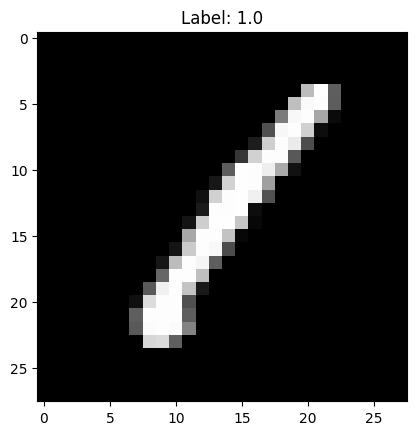

In [4]:
#Displatying the first image and its label
image = x_tensor[0].reshape(28, 28)
label = y_tensor[0]

plt.imshow(image, cmap='gray')
plt.title(f'Label: {label.item()}')
plt.show()


# Building the model

In [5]:
#Defining the model
class MLP(nn.Module):
    def  __init__(self):
          super().__init__()
          
          self.model = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    
    def forward(self, x):
        return self.model(x)

#Instantiating the model
model = MLP()

#Defining the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [6]:
epochs = 10

#Training loop
for epoch in range(epochs):
    total_loss = 0

    #
    for images , labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels.long())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

# Predictions 

In [7]:
#Calculating the average loss for the epoch
X_test = test_df / 255.0
X_test = torch.tensor(X_test.values, dtype=torch.float32)

In [8]:
predictions = []

#Making predictions on the test set
with torch.no_grad():
    for i in range(len(X_test)):
        output = model(X_test[i].unsqueeze(0))
        _, pred = torch.max(output, 1)
        predictions.append(pred.item())

In [10]:
#Comparing the predicted to the actual labels 
images, labels = next(iter(train_loader))

outputs = model(images)
_, predicted = torch.max(outputs, 1)

print("Predicted:", predicted[:10])
print("Actual:   ", labels[:10])

Predicted: tensor([8, 9, 9, 7, 4, 4, 4, 8, 7, 7])
Actual:    tensor([8., 9., 9., 7., 4., 4., 4., 8., 7., 7.])
